# Transfer Learning on Images - Dog Breed Classification

In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# Load Dataset

In [2]:
# Load Stanford Dogs Dataset (only 20 classes for simplicity)
builder = tfds.builder("stanford_dogs")
builder.download_and_prepare()
dataset = builder.as_dataset(as_supervised=True)

train_ds = dataset["train"]
test_ds = dataset["test"]

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

...

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/stanford_dogs/incomplete.U221L2_0.2.0/stanford_dogs-train.tfrecord*...:   …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/stanford_dogs/incomplete.U221L2_0.2.0/stanford_dogs-test.tfrecord*...:   0…

Dataset stanford_dogs downloaded and prepared to /root/tensorflow_datasets/stanford_dogs/0.2.0. Subsequent calls will reuse this data.


In [3]:
# Filter top 20 breeds for simplicity
NUM_CLASSES = 20

# Top Class Labels

In [4]:
# Get top 20 class labels from dataset
top_classes = []
for _, label in train_ds.take(1000):
    if label.numpy() not in top_classes:
        top_classes.append(label.numpy())
    if len(top_classes) == NUM_CLASSES:
        break

In [5]:
# Convert to tf.constant
top_classes_tf = tf.constant(top_classes, dtype=tf.int64)

def filter_fn(img, label):
    return tf.reduce_any(tf.equal(label, top_classes_tf))

def remap_fn(img, label):
    new_label = tf.cast(tf.where(tf.equal(top_classes_tf, label))[0][0], tf.int64)
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf.image.resize_with_pad(img, 224, 224)  # ensure consistent shape
    return img, new_label

train_ds = train_ds.filter(filter_fn).map(remap_fn, num_parallel_calls=tf.data.AUTOTUNE).cache().shuffle(1000).batch(32).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.filter(filter_fn).map(remap_fn, num_parallel_calls=tf.data.AUTOTUNE).batch(32).cache().prefetch(tf.data.AUTOTUNE)

# Preprocessing

In [6]:
# Preprocess layer
resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(224, 224), # Resizes images to a consistent shape
    layers.Rescaling(1./255)
])

# Feature Extraction Model

In [7]:
# Feature extraction model with EfficientNetB0
base_model = tf.keras.applications.EfficientNetB0(input_shape=(224,224,3), include_top=False, weights='imagenet')
base_model.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [8]:
# Feature Extraction
model_fe = models.Sequential([
    resize_and_rescale,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model_fe.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_fe = model_fe.fit(train_ds, epochs=5, validation_data=test_ds)

Epoch 1/5
     63/Unknown 48s 274ms/step - accuracy: 0.0532 - loss: 3.0373

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


63/63 ━━━━━━━━━━━━━━━━━━━━ 68s 599ms/step - accuracy: 0.0530 - loss: 3.0371 - val_accuracy: 0.0342 - val_loss: 2.9964
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 66s 662ms/step - accuracy: 0.0465 - loss: 2.9959 - val_accuracy: 0.0390 - val_loss: 2.9965
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 82s 662ms/step - accuracy: 0.0413 - loss: 2.9960 - val_accuracy: 0.0342 - val_loss: 2.9965
Epoch 4/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.0591 - loss: 2.9956 - val_accuracy: 0.0390 - val_loss: 2.9964
Epoch 5/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.0510 - loss: 2.9960 - val_accuracy: 0.0390 - val_loss: 2.9963


# Fine-tuning

In [9]:
# Fine-tuning from middle layers
base_model.trainable = True
fine_tune_at = len(base_model.layers) // 2
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model_ft = models.Sequential([
    resize_and_rescale,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model_ft.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_ft = model_ft.fit(train_ds, epochs=5, validation_data=test_ds)

Epoch 1/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 88s 584ms/step - accuracy: 0.0510 - loss: 3.0444 - val_accuracy: 0.0349 - val_loss: 3.0188
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - accuracy: 0.0424 - loss: 3.0270 - val_accuracy: 0.0562 - val_loss: 3.0066
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 91ms/step - accuracy: 0.0566 - loss: 3.0317 - val_accuracy: 0.0753 - val_loss: 3.0017
Epoch 4/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 165ms/step - accuracy: 0.0458 - loss: 3.0215 - val_accuracy: 0.0384 - val_loss: 3.0307
Epoch 5/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 92ms/step - accuracy: 0.0444 - loss: 3.0153 - val_accuracy: 0.0384 - val_loss: 3.0897


# Plotting

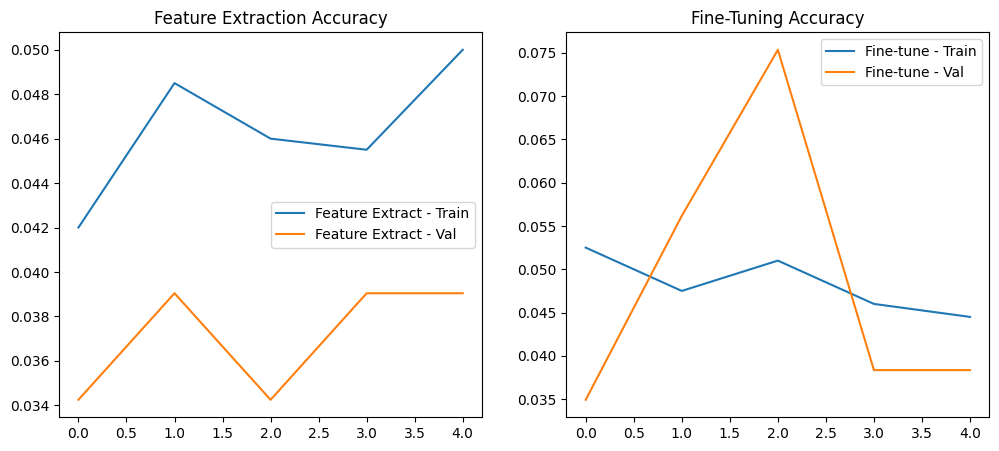

In [10]:
# Plotting
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history_fe.history['accuracy'], label='Feature Extract - Train')
plt.plot(history_fe.history['val_accuracy'], label='Feature Extract - Val')
plt.title("Feature Extraction Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_ft.history['accuracy'], label='Fine-tune - Train')
plt.plot(history_ft.history['val_accuracy'], label='Fine-tune - Val')
plt.title("Fine-Tuning Accuracy")
plt.legend()
plt.show()

# Predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


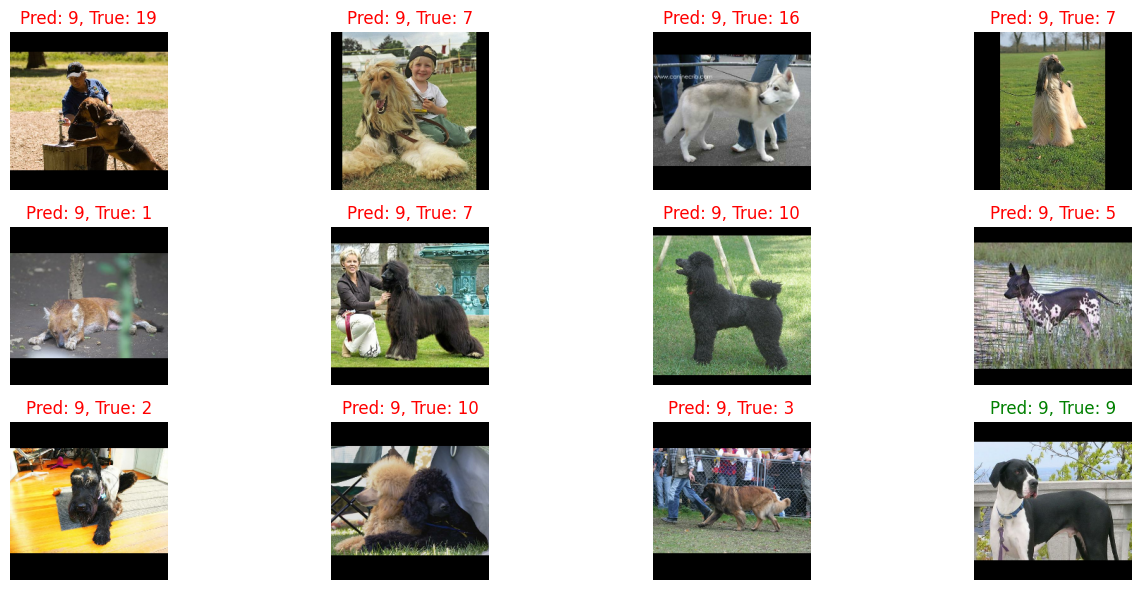

In [11]:
# Visualize predictions from test set
import random

# Class labels for display (numerical indices)
class_names = list(range(NUM_CLASSES))

# Get a small batch from the test dataset
for images, labels in test_ds.unbatch().batch(12).take(1):
    preds = model_ft.predict(images)
    pred_labels = tf.argmax(preds, axis=1)

    plt.figure(figsize=(14, 6))
    for i in range(len(images)):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy())
        true_label = labels[i].numpy()
        predicted = pred_labels[i].numpy()
        color = "green" if predicted == true_label else "red"
        plt.title(f"Pred: {predicted}, True: {true_label}", color=color)
        plt.axis("off")
    plt.tight_layout()
    plt.show()
